# MMWQI Forecasting — Predicting Marine Water Quality Index by Station

**Data:** 188 coastal monitoring stations across 13 Malaysian states, annual
MMWQI scores for 2021–2025.

**Goal:** predict the 2026 MMWQI score (and quality category) for every station.

**Approach:** with only 5 observations per station, heavy time-series models
(ARIMA, LSTM) would overfit badly. Instead we compare a family of simple,
robust forecasters plus one global machine-learning model, pick the winner by
honest backtesting (hold out 2025), then refit on all data to forecast 2026.

**Sections**
1. Setup and data loading
2. Exploratory analysis and charts
3. Forecasting methods
4. Backtest (train ≤2024 → predict 2025)
5. Model comparison and error diagnostics
6. Final 2026 forecast per station + prediction intervals
7. Forecast visualisation
8. Export results

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.autolayout": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

def boxplot_compat(ax, data, labels, **kw):
    """matplotlib renamed boxplot's `labels` to `tick_labels` in 3.9."""
    try:
        return ax.boxplot(data, tick_labels=labels, **kw)
    except TypeError:
        return ax.boxplot(data, labels=labels, **kw)

# Path to the source workbook — change if you run this elsewhere.
DATA_PATH = "mmwqi.xlsx"

In [2]:
# ── Load and tidy ─────────────────────────────────────────────────────────────
raw = pd.read_excel(DATA_PATH)

# Rename the bilingual headers to short English names.
rename_map = {
    "NEGERI/ STATE": "state",
    "KLASIFIKASI STESEN/ STATION CLASSIFICATION": "classification",
    "KAWASAN/ AREA": "area",
    "NOMBOR STESEN/ STATION NUMBER": "station",
    "KATEGORI (2025)": "category_2025",
}
df = raw.rename(columns=rename_map)

# Year columns are whatever headers parse as a 4-digit year.
def _is_year(c):
    try:
        return 1900 <= int(str(c)) <= 2100
    except (TypeError, ValueError):
        return False

YEAR_COLS = sorted([c for c in df.columns if _is_year(c)], key=lambda c: int(str(c)))
YEARS = np.array([int(str(c)) for c in YEAR_COLS])
LAST_YEAR = int(YEARS[-1])
FORECAST_YEAR = LAST_YEAR + 1

df[YEAR_COLS] = df[YEAR_COLS].apply(pd.to_numeric, errors="coerce")

print(f"Rows: {len(df)}   Stations: {df['station'].nunique()}   States: {df['state'].nunique()}")
print(f"Year columns: {list(YEARS)}  ->  forecasting {FORECAST_YEAR}")
print(f"Missing score cells: {int(df[YEAR_COLS].isna().sum().sum())}")
df.head()

Rows: 188   Stations: 188   States: 13
Year columns: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]  ->  forecasting 2026
Missing score cells: 0


,state,classification,area,station,2021,2022,2023,2024,2025,category_2025
0,Kedah,Pantai/Coastal,Pantai Merdeka,MMKC001,85,88,91,92,88,Baik/Good
1,Kedah,Pantai/Coastal,Langkawi Island Resort,MMKC002,94,94,96,95,96,Terbaik/Excellent
2,Kedah,Pantai/Coastal,Pantai Kok,MMKC003,90,83,95,96,96,Terbaik/Excellent
3,Kedah,Pantai/Coastal,Pantai Kuah,MMKC004,88,90,91,95,91,Terbaik/Excellent
4,Kedah,Pantai/Coastal,Pantai Pasir Tengkorak,MMKC005,96,93,93,95,95,Terbaik/Excellent


In [3]:
# ── MMWQI category bands (DOE Malaysia) ───────────────────────────────────────
# Excellent ≥ 90 | Good 80–89 | Moderate 51–79 | Poor ≤ 50
def mmwqi_category(score):
    if pd.isna(score):
        return np.nan
    if score >= 90:
        return "Excellent"
    if score >= 80:
        return "Good"
    if score >= 51:
        return "Moderate"
    return "Poor"

CAT_ORDER = ["Poor", "Moderate", "Good", "Excellent"]
CAT_COLOR = {"Poor": "#b2182b", "Moderate": "#ef8a62", "Good": "#67a9cf", "Excellent": "#2166ac"}

# Sanity check: do our bands reproduce the sheet's own 2025 labels?
check = pd.DataFrame({
    "sheet_label": df["category_2025"].str.split("/").str[-1].str.strip(),
    "our_label": df[LAST_YEAR].map(mmwqi_category),
})
agreement = (check["sheet_label"] == check["our_label"]).mean()
print(f"Category rule reproduces the workbook's {LAST_YEAR} labels: {agreement:.1%}")
check.value_counts().to_frame("n")

Category rule reproduces the workbook's 2025 labels: 100.0%


,,n
sheet_label,our_label,
Excellent,Excellent,92
Moderate,Moderate,55
Good,Good,41


In [4]:
# ── Long format (one row per station-year) — convenient for plotting ──────────
long = df.melt(
    id_vars=["state", "area", "station", "classification"],
    value_vars=YEAR_COLS, var_name="year", value_name="mmwqi",
)
long["year"] = long["year"].astype(int)
long["category"] = long["mmwqi"].map(mmwqi_category)
long.head()

,state,area,station,classification,year,mmwqi,category
0,Kedah,Pantai Merdeka,MMKC001,Pantai/Coastal,2021,85,Good
1,Kedah,Langkawi Island Resort,MMKC002,Pantai/Coastal,2021,94,Excellent
2,Kedah,Pantai Kok,MMKC003,Pantai/Coastal,2021,90,Excellent
3,Kedah,Pantai Kuah,MMKC004,Pantai/Coastal,2021,88,Good
4,Kedah,Pantai Pasir Tengkorak,MMKC005,Pantai/Coastal,2021,96,Excellent


## 2. Exploratory analysis

Before forecasting, look at how scores are distributed, whether there is a
national trend, and how volatile individual stations are. The answers decide
which forecasting methods are even plausible.

In [5]:
summary = long.groupby("year")["mmwqi"].agg(["count", "mean", "std", "min", "median", "max"]).round(2)
print(summary)

# Year-on-year volatility per station — how much does a station move in a year?
yoy = df[YEAR_COLS].diff(axis=1).iloc[:, 1:]
print(f"\nMean |year-on-year change| per station: {yoy.abs().to_numpy().mean():.2f} points")
print(f"Std of year-on-year change:            {yoy.to_numpy().std():.2f} points")

      count   mean    std  min  median  max
year                                       
2021    188  82.32  12.96   54    88.0   97
2022    188  81.95  14.38   50    89.0   97
2023    188  82.09  15.82   54    92.0   97
2024    188  84.06  13.82   54    92.0   97
2025    188  84.54  11.62   52    89.0   96

Mean |year-on-year change| per station: 5.30 points
Std of year-on-year change:            8.33 points


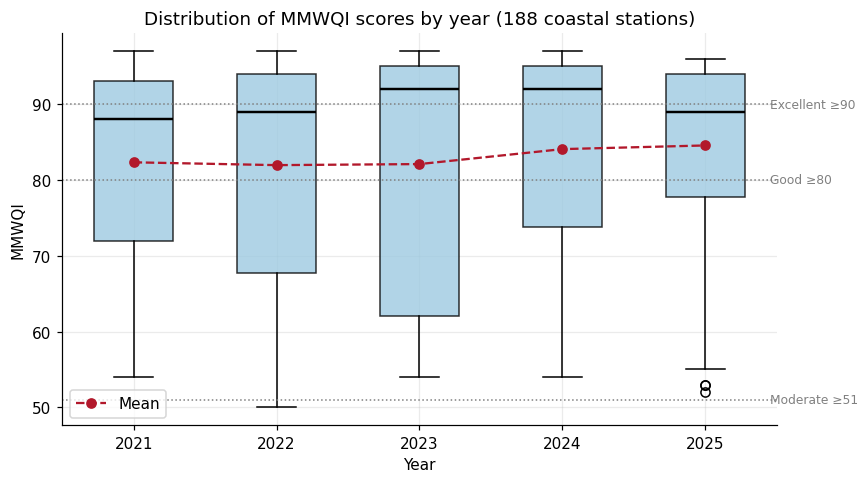

In [6]:
# ── Chart 1: distribution of scores by year ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
data_by_year = [long.loc[long["year"] == y, "mmwqi"].dropna().values for y in YEARS]
bp = boxplot_compat(ax, data_by_year, [str(y) for y in YEARS], patch_artist=True,
                    widths=0.55, medianprops=dict(color="black", lw=1.6))
for patch in bp["boxes"]:
    patch.set_facecolor("#9ecae1")
    patch.set_alpha(0.8)
means = [np.nanmean(v) for v in data_by_year]
ax.plot(range(1, len(YEARS) + 1), means, "o--", color="#b2182b", lw=1.5, label="Mean")
for band, lbl in [(90, "Excellent ≥90"), (80, "Good ≥80"), (51, "Moderate ≥51")]:
    ax.axhline(band, color="grey", ls=":", lw=1)
    ax.text(len(YEARS) + 0.45, band, lbl, va="center", fontsize=8, color="grey")
ax.set_title("Distribution of MMWQI scores by year (188 coastal stations)")
ax.set_xlabel("Year"); ax.set_ylabel("MMWQI")
ax.legend(loc="lower left")
plt.show()

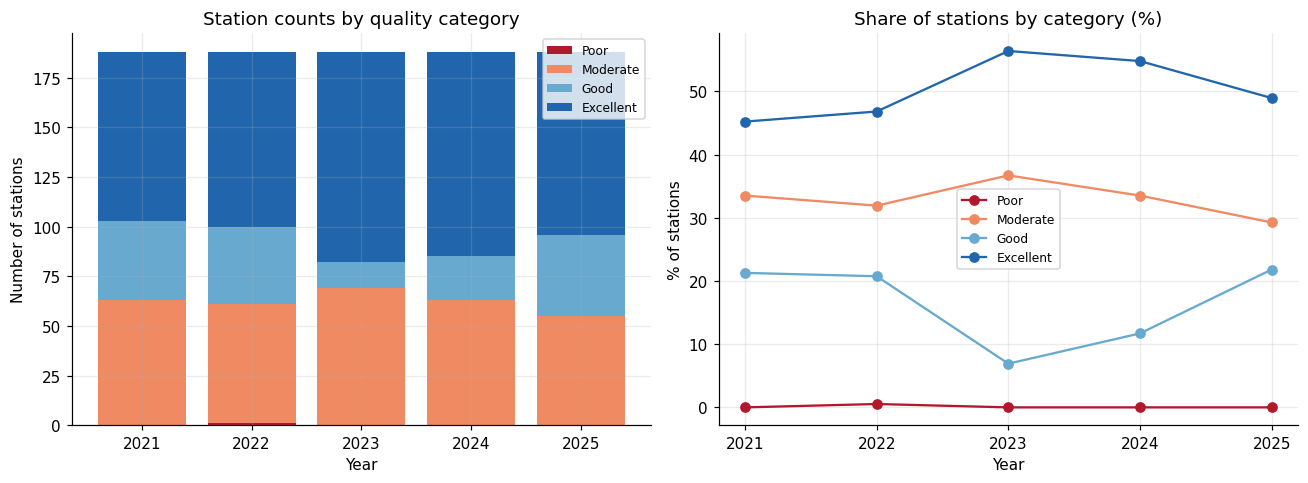

category,Poor,Moderate,Good,Excellent
year,,,,
2021,0,63,40,85
2022,1,60,39,88
2023,0,69,13,106
2024,0,63,22,103
2025,0,55,41,92


In [7]:
# ── Chart 2: category composition over time ───────────────────────────────────
comp = (long.pivot_table(index="year", columns="category", values="station", aggfunc="count")
            .reindex(columns=CAT_ORDER).fillna(0))
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bottom = np.zeros(len(comp))
for cat in CAT_ORDER:
    axes[0].bar(comp.index.astype(str), comp[cat], bottom=bottom,
                label=cat, color=CAT_COLOR[cat])
    bottom += comp[cat].values
axes[0].set_title("Station counts by quality category")
axes[0].set_ylabel("Number of stations"); axes[0].set_xlabel("Year")
axes[0].legend(fontsize=8)

for cat in CAT_ORDER:
    if comp_pct[cat].sum() > 0:
        axes[1].plot(comp_pct.index, comp_pct[cat], "o-", label=cat, color=CAT_COLOR[cat])
axes[1].set_title("Share of stations by category (%)")
axes[1].set_ylabel("% of stations"); axes[1].set_xlabel("Year")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend(fontsize=8)
plt.show()

comp.astype(int)

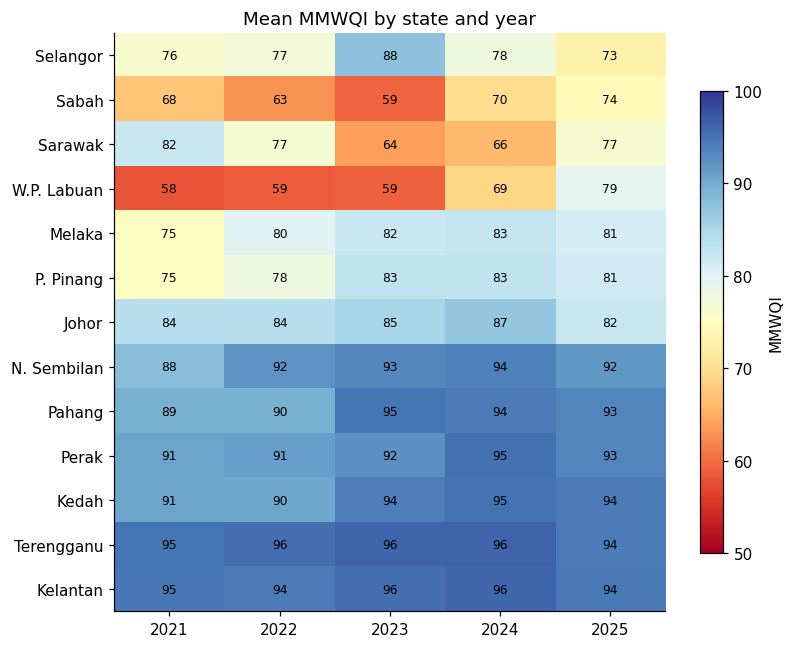

In [8]:
# ── Chart 3: state-level mean MMWQI heatmap ───────────────────────────────────
state_year = long.pivot_table(index="state", columns="year", values="mmwqi", aggfunc="mean")
state_year = state_year.loc[state_year[LAST_YEAR].sort_values().index]  # worst at bottom

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(state_year.values, cmap="RdYlBu", aspect="auto", vmin=50, vmax=100)
ax.set_xticks(range(len(state_year.columns)), state_year.columns)
ax.set_yticks(range(len(state_year.index)), state_year.index)
for i in range(state_year.shape[0]):
    for j in range(state_year.shape[1]):
        ax.text(j, i, f"{state_year.values[i, j]:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("Mean MMWQI by state and year")
fig.colorbar(im, ax=ax, label="MMWQI", shrink=0.8)
ax.grid(False)
plt.show()

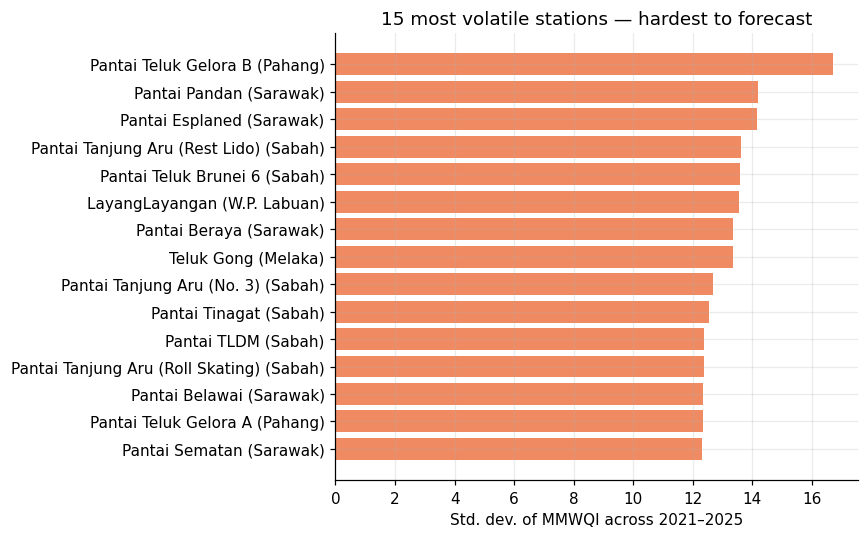

In [9]:
# ── Chart 4: which stations are most volatile? ────────────────────────────────
vol = pd.DataFrame({
    "station": df["station"], "area": df["area"], "state": df["state"],
    "mean": df[YEAR_COLS].mean(axis=1),
    "std": df[YEAR_COLS].std(axis=1),
    "range": df[YEAR_COLS].max(axis=1) - df[YEAR_COLS].min(axis=1),
})
top_vol = vol.nlargest(15, "std")

fig, ax = plt.subplots(figsize=(8, 5))
labels = top_vol["area"] + " (" + top_vol["state"] + ")"
ax.barh(labels[::-1], top_vol["std"][::-1], color="#ef8a62")
ax.set_xlabel("Std. dev. of MMWQI across 2021–2025")
ax.set_title("15 most volatile stations — hardest to forecast")
plt.show()

## 3. Forecasting methods

Each method takes a station's history and returns a prediction for a target
year. All are deliberately simple — with 5 points, anything more elaborate
fits noise.

| Method | Idea |
|---|---|
| `naive` | next year = this year (persistence) |
| `mean` | long-run station average |
| `ma2` | average of the last two years |
| `linear` | OLS straight-line trend extrapolated forward |
| `damped(φ)` | last value + φ × trend slope (shrinks the trend) |
| `ses(α)` | simple exponential smoothing |
| `naive+drift` | last value + average historical change |
| `blend` | equal-weight average of naive, mean and damped |

A global **Random Forest** and a **Ridge** regression on lag features are
added later — they can borrow strength across all 188 stations.

In [10]:
def f_naive(years, vals, target):
    return vals[-1]

def f_mean(years, vals, target):
    return np.mean(vals)

def f_ma2(years, vals, target):
    return np.mean(vals[-2:])

def f_linear(years, vals, target):
    slope, intercept = np.polyfit(years, vals, 1)
    return intercept + slope * target

def make_damped(phi):
    def f(years, vals, target):
        slope, _ = np.polyfit(years, vals, 1)
        return vals[-1] + phi * slope * (target - years[-1])
    f.__name__ = f"damped({phi})"
    return f

def make_ses(alpha):
    def f(years, vals, target):
        level = vals[0]
        for v in vals[1:]:
            level = alpha * v + (1 - alpha) * level
        return level
    f.__name__ = f"ses({alpha})"
    return f

def f_drift(years, vals, target):
    if len(vals) < 2:
        return vals[-1]
    drift = (vals[-1] - vals[0]) / (years[-1] - years[0])
    return vals[-1] + drift * (target - years[-1])

def f_blend(years, vals, target):
    return np.mean([f_naive(years, vals, target),
                    f_mean(years, vals, target),
                    make_damped(0.4)(years, vals, target)])

METHODS = {
    "naive": f_naive,
    "mean": f_mean,
    "ma2": f_ma2,
    "linear": f_linear,
    "damped(0.3)": make_damped(0.3),
    "damped(0.5)": make_damped(0.5),
    "ses(0.3)": make_ses(0.3),
    "ses(0.5)": make_ses(0.5),
    "ses(0.7)": make_ses(0.7),
    "naive+drift": f_drift,
    "blend": f_blend,
}

def clip_score(x):
    """MMWQI is bounded 0–100."""
    return float(np.clip(x, 0, 100))

## 4. Backtest

The honest test: hide 2025, fit each method on 2021–2024, predict 2025, and
compare to what actually happened. A second fold (fit 2021–2022, predict 2023;
fit 2021–2023, predict 2024) gives a sanity check that the ranking is stable.

In [11]:
def backtest(method_fn, train_years, target_year, frame=df):
    """Predict `target_year` for every station using only `train_years`."""
    tr_cols = [c for c in YEAR_COLS if int(str(c)) in train_years]
    ty = np.array([int(str(c)) for c in tr_cols], dtype=float)
    preds = []
    for _, row in frame.iterrows():
        vals = row[tr_cols].to_numpy(dtype=float)
        preds.append(clip_score(method_fn(ty, vals, float(target_year))))
    return np.array(preds)

def score_preds(y_true, y_pred):
    cat_true = pd.Series(y_true).map(mmwqi_category)
    cat_pred = pd.Series(y_pred).map(mmwqi_category)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MedAE": float(np.median(np.abs(y_true - y_pred))),
        "MAPE_%": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        "R2": r2_score(y_true, y_pred),
        "CatAcc_%": float((cat_true == cat_pred).mean() * 100),
    }

y_true_2025 = df[LAST_YEAR].to_numpy(dtype=float)
train_years_main = [int(y) for y in YEARS[:-1]]

rows, pred_store = [], {}
for name, fn in METHODS.items():
    p = backtest(fn, train_years_main, LAST_YEAR)
    pred_store[name] = p
    rows.append({"model": name, **score_preds(y_true_2025, p)})

results = pd.DataFrame(rows).set_index("model").sort_values("MAE").round(3)
print(f"Backtest — train {train_years_main} → predict {LAST_YEAR}")
results

Backtest — train [2021, 2022, 2023, 2024] → predict 2025


,MAE,RMSE,MedAE,MAPE_%,R2,CatAcc_%
model,,,,,,
ses(0.3),4.790,7.493,2.612,5.992,0.582,76.064
mean,4.903,7.759,2.500,6.120,0.552,76.064
ses(0.5),4.984,7.802,2.500,6.273,0.547,78.723
blend,5.299,8.102,2.732,6.713,0.511,73.404
ses(0.7),5.339,8.198,2.630,6.756,0.500,76.064
naive,5.665,8.580,3.000,7.214,0.452,75.000
ma2,5.731,8.756,3.000,7.260,0.429,78.191
damped(0.3),6.154,9.216,3.285,7.841,0.368,75.000
damped(0.5),6.535,9.688,3.700,8.327,0.301,75.000


In [12]:
# ── Fold 2: predict 2024 from 2021–2023, to check the ranking is stable ───────
prev_year = int(YEARS[-2])
y_true_prev = df[prev_year].to_numpy(dtype=float)
rows2 = []
for name, fn in METHODS.items():
    p = backtest(fn, [int(y) for y in YEARS[:-2]], prev_year)
    rows2.append({"model": name, **score_preds(y_true_prev, p)})
results_fold2 = pd.DataFrame(rows2).set_index("model").sort_values("MAE").round(3)
print(f"Backtest fold 2 — train {[int(y) for y in YEARS[:-2]]} → predict {prev_year}")
results_fold2[["MAE", "RMSE", "CatAcc_%"]]

Backtest fold 2 — train [2021, 2022, 2023] → predict 2024


,MAE,RMSE,CatAcc_%
model,,,
ses(0.7),4.239,6.664,87.766
blend,4.287,6.878,88.830
ma2,4.372,6.878,84.043
naive,4.527,7.358,87.766
ses(0.5),4.537,6.833,81.915
mean,4.998,7.326,77.128
damped(0.3),5.127,8.118,85.638
ses(0.3),5.344,7.754,74.468
damped(0.5),5.657,8.756,82.979


### Global machine-learning models

Statistical methods look at one station in isolation. A global model pools all
stations: it learns patterns like *"a station at 70 that dropped 5 points last
year tends to rebound"*. Features are three lags plus simple derived
statistics and the state (one-hot).

With 5 years of data and a 3-lag window we get exactly two training rows per
station, so we train on the 2024 target and test on the 2025 target.

In [13]:
def build_ml_frame(frame, lag_years, target_year=None):
    """Features from three consecutive years; target is the following year."""
    lag_cols = [c for c in YEAR_COLS if int(str(c)) in lag_years]
    lag_cols = sorted(lag_cols, key=lambda c: int(str(c)))
    L = frame[lag_cols].to_numpy(dtype=float)          # columns: t-3, t-2, t-1
    X = pd.DataFrame({
        "lag1": L[:, -1],
        "lag2": L[:, -2],
        "lag3": L[:, -3],
        "mean3": L.mean(axis=1),
        "std3": L.std(axis=1),
        "diff1": L[:, -1] - L[:, -2],
        "diff2": L[:, -2] - L[:, -3],
        "range3": L.max(axis=1) - L.min(axis=1),
        "min3": L.min(axis=1),
        "max3": L.max(axis=1),
    })
    X = pd.concat([X, pd.get_dummies(frame["state"], prefix="st").reset_index(drop=True)], axis=1)
    y = frame[target_year].to_numpy(dtype=float) if target_year is not None else None
    return X, y

lag_train = [int(y) for y in YEARS[-5:-2]]   # 2021, 2022, 2023 -> 2024
lag_test = [int(y) for y in YEARS[-4:-1]]    # 2022, 2023, 2024 -> 2025

X_tr, y_tr = build_ml_frame(df, lag_train, prev_year)
X_te, y_te = build_ml_frame(df, lag_test, LAST_YEAR)
X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)

rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=3,
                           max_features=0.6, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)
p_rf = np.clip(rf.predict(X_te), 0, 100)

ridge = Ridge(alpha=5.0).fit(X_tr, y_tr)
p_ridge = np.clip(ridge.predict(X_te), 0, 100)

pred_store["RandomForest"] = p_rf
pred_store["Ridge(lags)"] = p_ridge
for nm, p in [("RandomForest", p_rf), ("Ridge(lags)", p_ridge)]:
    results.loc[nm] = pd.Series(score_preds(y_true_2025, p))

results = results.sort_values("MAE").round(3)
results

,MAE,RMSE,MedAE,MAPE_%,R2,CatAcc_%
model,,,,,,
ses(0.3),4.790,7.493,2.612,5.992,0.582,76.064
mean,4.903,7.759,2.500,6.120,0.552,76.064
ses(0.5),4.984,7.802,2.500,6.273,0.547,78.723
RandomForest,5.203,7.577,3.259,6.750,0.573,76.064
blend,5.299,8.102,2.732,6.713,0.511,73.404
ses(0.7),5.339,8.198,2.630,6.756,0.500,76.064
Ridge(lags),5.494,7.936,3.352,7.167,0.531,75.532
naive,5.665,8.580,3.000,7.214,0.452,75.000
ma2,5.731,8.756,3.000,7.260,0.429,78.191


In [14]:
BEST_MODEL = results.index[0]
print(f"Best model on the {LAST_YEAR} holdout: {BEST_MODEL}")
print(results.loc[BEST_MODEL].to_string())

Best model on the 2025 holdout: ses(0.3)
MAE          4.790
RMSE         7.493
MedAE        2.612
MAPE_%       5.992
R2           0.582
CatAcc_%    76.064


In [15]:
# ── Stability check: does the ranking hold across both folds? ─────────────────
# The two folds do not have to agree, and with 188 stations × 1 year of holdout
# the differences between the top few methods are within noise. What matters is
# that the *family* that wins is stable — if smoothing methods top both folds,
# the choice is safe even if the exact alpha differs.
stability = pd.DataFrame({
    f"rank_{LAST_YEAR}": results["MAE"].rank(),
    f"rank_{prev_year}": results_fold2["MAE"].rank(),
})
stability["avg_rank"] = stability.mean(axis=1)
stability.sort_values("avg_rank").round(2)

,rank_2025,rank_2024,avg_rank
model,,,
blend,5.0,2.0,3.5
ses(0.7),6.0,1.0,3.5
mean,2.0,6.0,4.0
RandomForest,4.0,NaN,4.0
ses(0.5),3.0,5.0,4.0
ses(0.3),1.0,8.0,4.5
naive,8.0,4.0,6.0
ma2,9.0,3.0,6.0
Ridge(lags),7.0,NaN,7.0


## 5. Error diagnostics

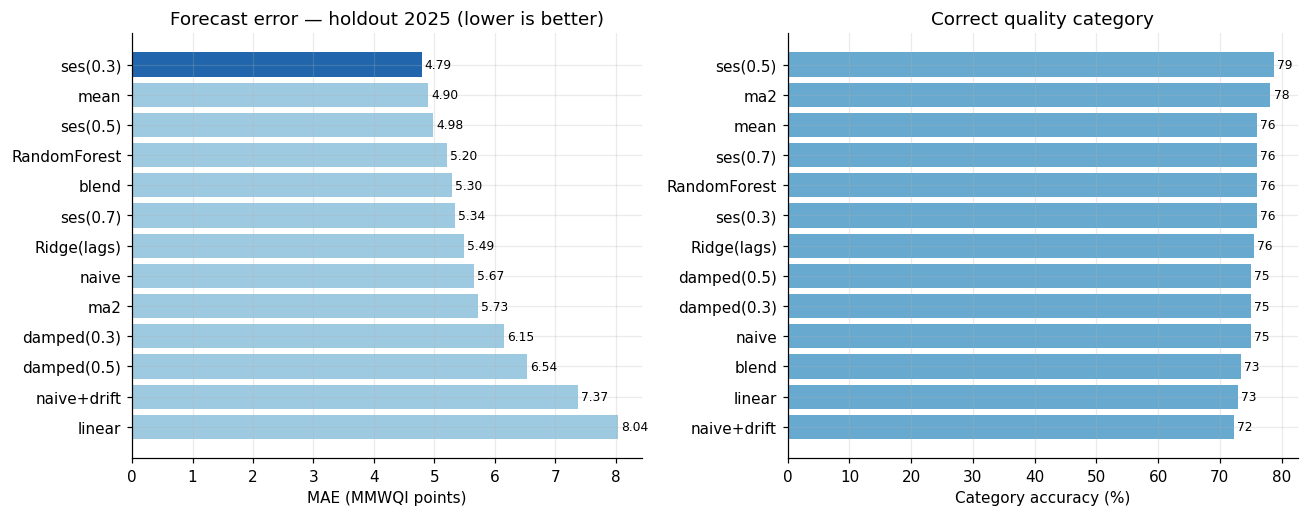

In [16]:
# ── Chart 5: model comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ordered = results.sort_values("MAE")
colors = ["#2166ac" if m == BEST_MODEL else "#9ecae1" for m in ordered.index]
axes[0].barh(ordered.index[::-1], ordered["MAE"][::-1], color=colors[::-1])
axes[0].set_xlabel("MAE (MMWQI points)")
axes[0].set_title(f"Forecast error — holdout {LAST_YEAR} (lower is better)")
for i, v in enumerate(ordered["MAE"][::-1]):
    axes[0].text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=8)

ordered_cat = results.sort_values("CatAcc_%")
axes[1].barh(ordered_cat.index, ordered_cat["CatAcc_%"], color="#67a9cf")
axes[1].set_xlabel("Category accuracy (%)")
axes[1].set_title("Correct quality category")
for i, v in enumerate(ordered_cat["CatAcc_%"]):
    axes[1].text(v + 0.5, i, f"{v:.0f}", va="center", fontsize=8)
plt.show()

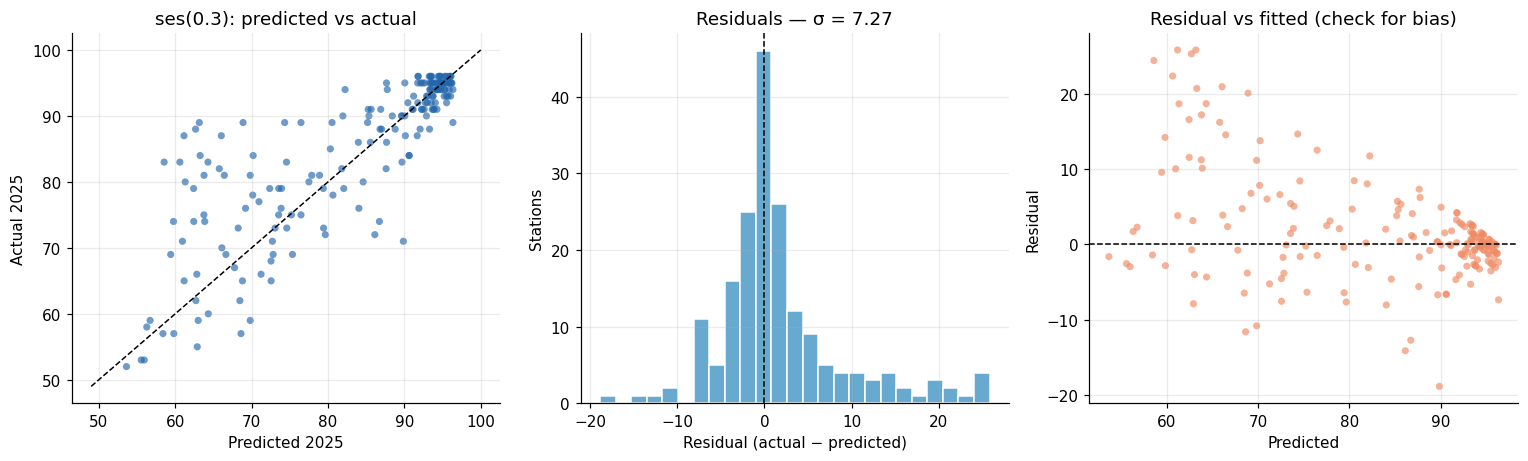

Bias (mean residual): +1.81 points
68% of stations within ±4.7 points
95% of stations within ±18.7 points


In [17]:
# ── Chart 6: predicted vs actual and residuals for the best model ─────────────
best_pred = pred_store[BEST_MODEL]
resid = y_true_2025 - best_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
axes[0].scatter(best_pred, y_true_2025, s=22, alpha=0.65, color="#2166ac", edgecolor="none")
lims = [min(best_pred.min(), y_true_2025.min()) - 3, 100]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel(f"Predicted {LAST_YEAR}"); axes[0].set_ylabel(f"Actual {LAST_YEAR}")
axes[0].set_title(f"{BEST_MODEL}: predicted vs actual")

axes[1].hist(resid, bins=25, color="#67a9cf", edgecolor="white")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Residual (actual − predicted)"); axes[1].set_ylabel("Stations")
axes[1].set_title(f"Residuals — σ = {resid.std():.2f}")

axes[2].scatter(best_pred, resid, s=22, alpha=0.65, color="#ef8a62", edgecolor="none")
axes[2].axhline(0, color="k", ls="--", lw=1)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Residual")
axes[2].set_title("Residual vs fitted (check for bias)")
plt.show()

print(f"Bias (mean residual): {resid.mean():+.2f} points")
print(f"68% of stations within ±{np.percentile(np.abs(resid), 68):.1f} points")
print(f"95% of stations within ±{np.percentile(np.abs(resid), 95):.1f} points")

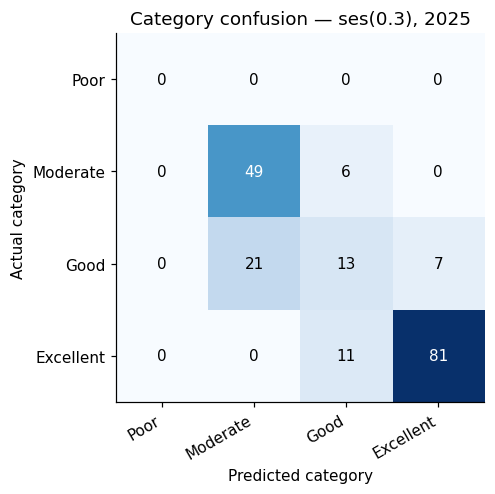

In [18]:
# ── Chart 7: category confusion matrix on the holdout year ────────────────────
cm_true = pd.Series(y_true_2025).map(mmwqi_category)
cm_pred = pd.Series(best_pred).map(mmwqi_category)
cm = pd.crosstab(cm_true, cm_pred).reindex(index=CAT_ORDER, columns=CAT_ORDER).fillna(0)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(len(CAT_ORDER)), CAT_ORDER, rotation=30, ha="right")
ax.set_yticks(range(len(CAT_ORDER)), CAT_ORDER)
for i in range(len(CAT_ORDER)):
    for j in range(len(CAT_ORDER)):
        v = int(cm.values[i, j])
        ax.text(j, i, v, ha="center", va="center",
                color="white" if v > cm.values.max() / 2 else "black")
ax.set_xlabel("Predicted category"); ax.set_ylabel("Actual category")
ax.set_title(f"Category confusion — {BEST_MODEL}, {LAST_YEAR}")
ax.grid(False)
plt.show()

## 6. Final forecast for every station

Refit the winning method on the **full** 2021–2025 history and predict 2026.
The prediction interval comes from the backtest residual spread — an empirical,
honest measure of how wrong this method was on a year it had never seen.

In [19]:
RESID_SD = float(resid.std(ddof=1))

if BEST_MODEL in METHODS:
    fn = METHODS[BEST_MODEL]
    final_pred = np.array([
        clip_score(fn(YEARS.astype(float),
                      df.loc[i, YEAR_COLS].to_numpy(dtype=float),
                      float(FORECAST_YEAR)))
        for i in df.index
    ])
else:  # a global ML model won — retrain it on both available windows
    X_all = pd.concat([X_tr, X_te], ignore_index=True)
    y_all = np.concatenate([y_tr, y_te])
    lag_final = [int(y) for y in YEARS[-3:]]
    X_fut, _ = build_ml_frame(df, lag_final)
    X_fut = X_fut.reindex(columns=X_all.columns, fill_value=0)
    model = (RandomForestRegressor(n_estimators=500, min_samples_leaf=3, max_features=0.6,
                                   random_state=RANDOM_STATE, n_jobs=-1)
             if BEST_MODEL == "RandomForest" else Ridge(alpha=5.0))
    model.fit(X_all, y_all)
    final_pred = np.clip(model.predict(X_fut), 0, 100)

forecast = df[["state", "area", "station"]].copy()
for c in YEAR_COLS:
    forecast[f"mmwqi_{int(str(c))}"] = df[c]
forecast[f"pred_{FORECAST_YEAR}"] = np.round(final_pred, 1)
forecast[f"pred_cat_{FORECAST_YEAR}"] = [mmwqi_category(v) for v in final_pred]
forecast["lower_95"] = np.round(np.clip(final_pred - 1.96 * RESID_SD, 0, 100), 1)
forecast["upper_95"] = np.round(np.clip(final_pred + 1.96 * RESID_SD, 0, 100), 1)
forecast[f"change_vs_{LAST_YEAR}"] = np.round(final_pred - df[LAST_YEAR].to_numpy(), 1)
forecast[f"cat_{LAST_YEAR}"] = df[LAST_YEAR].map(mmwqi_category)
forecast["category_change"] = np.where(
    forecast[f"pred_cat_{FORECAST_YEAR}"] == forecast[f"cat_{LAST_YEAR}"], "same",
    np.where(
        forecast[f"pred_cat_{FORECAST_YEAR}"].map(CAT_ORDER.index)
        > forecast[f"cat_{LAST_YEAR}"].map(CAT_ORDER.index), "improving", "declining"))

print(f"Model used: {BEST_MODEL}   |   95% interval: ±{1.96 * RESID_SD:.1f} points")
forecast.head(12)

Model used: ses(0.3)   |   95% interval: ±14.3 points


,state,area,station,mmwqi_2021,mmwqi_2022,mmwqi_2023,mmwqi_2024,mmwqi_2025,pred_2026,pred_cat_2026,lower_95,upper_95,change_vs_2025,cat_2025,category_change
0,Kedah,Pantai Merdeka,MMKC001,85,88,91,92,88,88.6,Good,74.3,100.0,0.6,Good,same
1,Kedah,Langkawi Island Resort,MMKC002,94,94,96,95,96,95.1,Excellent,80.8,100.0,-0.9,Excellent,same
2,Kedah,Pantai Kok,MMKC003,90,83,95,96,96,93.1,Excellent,78.8,100.0,-2.9,Excellent,same
3,Kedah,Pantai Kuah,MMKC004,88,90,91,95,91,91.0,Excellent,76.7,100.0,0.0,Excellent,same
4,Kedah,Pantai Pasir Tengkorak,MMKC005,96,93,93,95,95,94.7,Excellent,80.4,100.0,-0.3,Excellent,same
5,Kedah,Pantai Teluk Burau,MMKC006,94,86,96,94,96,94.1,Excellent,79.8,100.0,-1.9,Excellent,same
6,Kedah,Pantai Teluk Nibong,MMKC007,86,92,95,96,96,93.0,Excellent,78.7,100.0,-3.0,Excellent,same
7,Kedah,Pantai Tengah,MMKC008,92,92,94,96,95,94.0,Excellent,79.7,100.0,-1.0,Excellent,same
8,Kedah,Pantai Beras Basah,MMKC009,92,96,96,96,95,94.7,Excellent,80.4,100.0,-0.3,Excellent,same
9,P. Pinang,Gertak Sanggul,MMPC001,81,83,94,91,88,87.3,Good,73.0,100.0,-0.7,Good,same


In [20]:
# ── Headline numbers ──────────────────────────────────────────────────────────
print(f"Predicted {FORECAST_YEAR} national mean: {final_pred.mean():.2f} "
      f"(vs {df[LAST_YEAR].mean():.2f} in {LAST_YEAR})")
print("\nPredicted category mix:")
print(forecast[f"pred_cat_{FORECAST_YEAR}"].value_counts().reindex(CAT_ORDER).fillna(0).astype(int))
print("\nCategory movement vs last year:")
print(forecast["category_change"].value_counts())
print(f"\nStations predicted below 51 (Poor): {(final_pred < 51).sum()}")

Predicted 2026 national mean: 83.28 (vs 84.54 in 2025)

Predicted category mix:
pred_cat_2026
Poor          0
Moderate     70
Good         33
Excellent    85
Name: count, dtype: int64

Category movement vs last year:
category_change
same         148
declining     31
improving      9
Name: count, dtype: int64

Stations predicted below 51 (Poor): 0


In [21]:
# ── Stations of concern: lowest predicted scores ──────────────────────────────
watchlist = forecast.nsmallest(15, f"pred_{FORECAST_YEAR}")[
    ["state", "area", "station", f"mmwqi_{LAST_YEAR}", f"pred_{FORECAST_YEAR}",
     "lower_95", "upper_95", f"pred_cat_{FORECAST_YEAR}"]]
watchlist

,state,area,station,mmwqi_2025,pred_2026,lower_95,upper_95,pred_cat_2026
70,Johor,Pantai Lido,MMJC008,52,53.1,38.8,67.4,Moderate
66,Johor,Pantai Stulang Laut,MMJC004,53,54.8,40.5,69.1,Moderate
69,Johor,Hadapan HSAJB,MMJC007,53,55.1,40.8,69.4,Moderate
61,Melaka,Pulau Melaka Point B2,MMMC008,58,56.8,42.5,71.1,Moderate
60,Melaka,Pulau Melaka Point B1,MMMC007,59,57.4,43.1,71.7,Moderate
19,P. Pinang,Selat PP Selatan (Jelutong),MMPC011,57,58.0,43.7,72.3,Moderate
68,Johor,Pelabuhan Pasir Gudang,MMJC006,57,59.0,44.7,73.3,Moderate
37,Selangor,Selat Klang Utara,MMBC004,55,60.5,46.2,74.8,Moderate
171,Sabah,Pantai Dalit Tuaran,MMSC013,59,61.8,47.5,76.1,Moderate
178,Sabah,Pantai Ulu Tungku,MMSC020,65,62.3,48.0,76.6,Moderate


## 7. Forecast visualisation

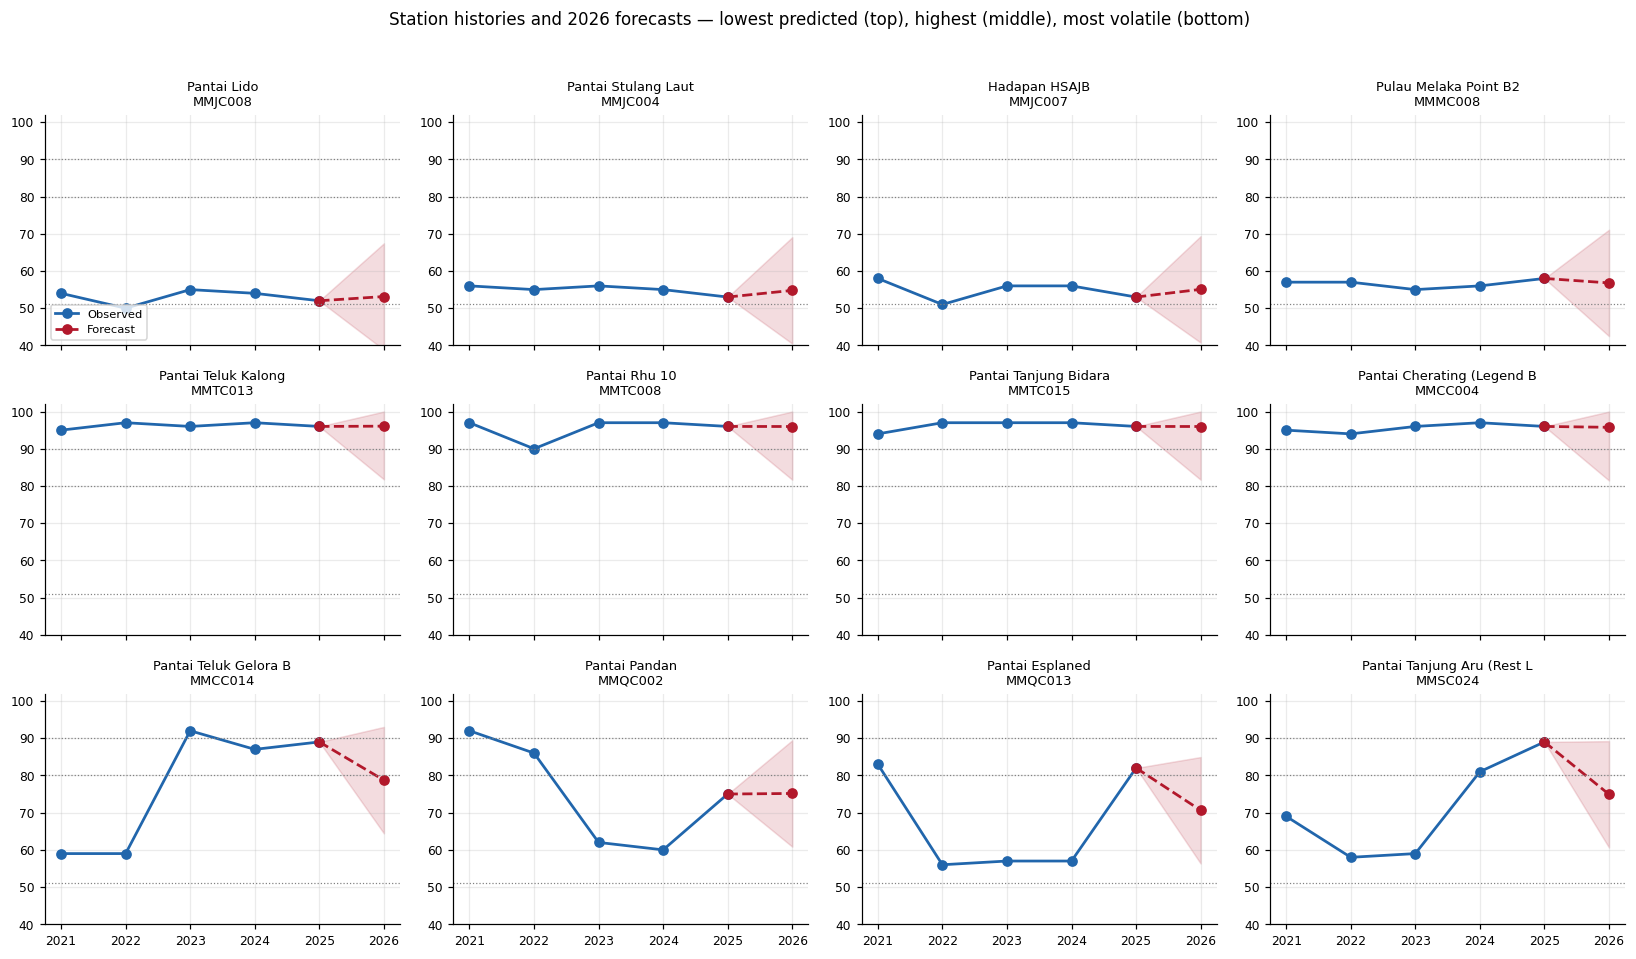

In [22]:
# ── Chart 8: history + forecast for a sample of stations ──────────────────────
sample_idx = list(forecast.nsmallest(4, f"pred_{FORECAST_YEAR}").index) \
           + list(forecast.nlargest(4, f"pred_{FORECAST_YEAR}").index) \
           + list(vol.nlargest(4, "std").index)

fig, axes = plt.subplots(3, 4, figsize=(15, 8.5), sharex=True)
for ax, idx in zip(axes.ravel(), sample_idx):
    hist = df.loc[idx, YEAR_COLS].to_numpy(dtype=float)
    ax.plot(YEARS, hist, "o-", color="#2166ac", lw=1.8, label="Observed")
    ax.plot([YEARS[-1], FORECAST_YEAR], [hist[-1], final_pred[idx]],
            "o--", color="#b2182b", lw=1.8, label="Forecast")
    ax.fill_between([YEARS[-1], FORECAST_YEAR],
                    [hist[-1], max(0, final_pred[idx] - 1.96 * RESID_SD)],
                    [hist[-1], min(100, final_pred[idx] + 1.96 * RESID_SD)],
                    color="#b2182b", alpha=0.15)
    for band in (90, 80, 51):
        ax.axhline(band, color="grey", ls=":", lw=0.8)
    ax.set_title(f"{df.loc[idx, 'area'][:26]}\n{df.loc[idx, 'station']}", fontsize=8.5)
    ax.set_ylim(40, 102)
    ax.tick_params(labelsize=8)
axes[0, 0].legend(fontsize=7.5, loc="lower left")
fig.suptitle(f"Station histories and {FORECAST_YEAR} forecasts — "
             "lowest predicted (top), highest (middle), most volatile (bottom)",
             fontsize=11, y=1.02)
plt.show()

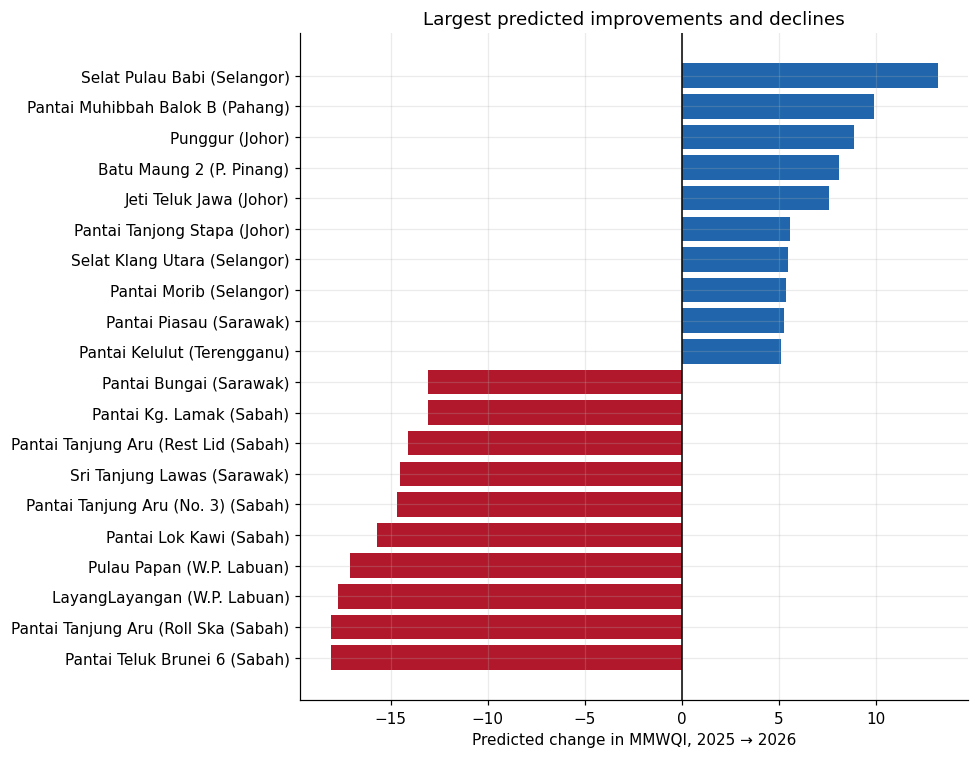

In [23]:
# ── Chart 9: biggest predicted movers ─────────────────────────────────────────
movers = pd.concat([forecast.nlargest(10, f"change_vs_{LAST_YEAR}"),
                    forecast.nsmallest(10, f"change_vs_{LAST_YEAR}")])
movers = movers.sort_values(f"change_vs_{LAST_YEAR}")
labels = movers["area"].str.slice(0, 28) + " (" + movers["state"] + ")"
colors = np.where(movers[f"change_vs_{LAST_YEAR}"] >= 0, "#2166ac", "#b2182b")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(labels, movers[f"change_vs_{LAST_YEAR}"], color=colors)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel(f"Predicted change in MMWQI, {LAST_YEAR} → {FORECAST_YEAR}")
ax.set_title("Largest predicted improvements and declines")
plt.show()

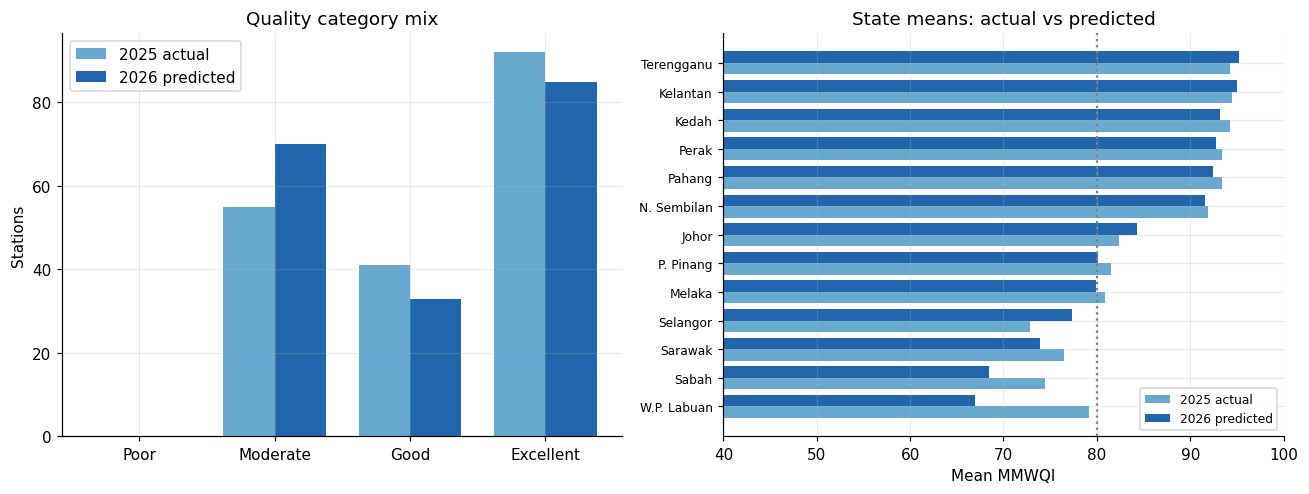

In [24]:
# ── Chart 10: category mix, last observed year vs forecast ────────────────────
last_counts = df[LAST_YEAR].map(mmwqi_category).value_counts().reindex(CAT_ORDER).fillna(0)
pred_counts = forecast[f"pred_cat_{FORECAST_YEAR}"].value_counts().reindex(CAT_ORDER).fillna(0)

x = np.arange(len(CAT_ORDER)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].bar(x - w / 2, last_counts, w, label=f"{LAST_YEAR} actual", color="#67a9cf")
axes[0].bar(x + w / 2, pred_counts, w, label=f"{FORECAST_YEAR} predicted", color="#2166ac")
axes[0].set_xticks(x, CAT_ORDER)
axes[0].set_ylabel("Stations"); axes[0].set_title("Quality category mix")
axes[0].legend()

state_pred = (forecast.groupby("state")
              .agg(actual=(f"mmwqi_{LAST_YEAR}", "mean"),
                   predicted=(f"pred_{FORECAST_YEAR}", "mean"))
              .sort_values("predicted"))
y = np.arange(len(state_pred))
axes[1].barh(y - 0.2, state_pred["actual"], 0.4, label=f"{LAST_YEAR} actual", color="#67a9cf")
axes[1].barh(y + 0.2, state_pred["predicted"], 0.4, label=f"{FORECAST_YEAR} predicted", color="#2166ac")
axes[1].set_yticks(y, state_pred.index, fontsize=8)
axes[1].set_xlim(40, 100); axes[1].axvline(80, color="grey", ls=":")
axes[1].set_xlabel("Mean MMWQI"); axes[1].set_title("State means: actual vs predicted")
axes[1].legend(fontsize=8)
plt.show()

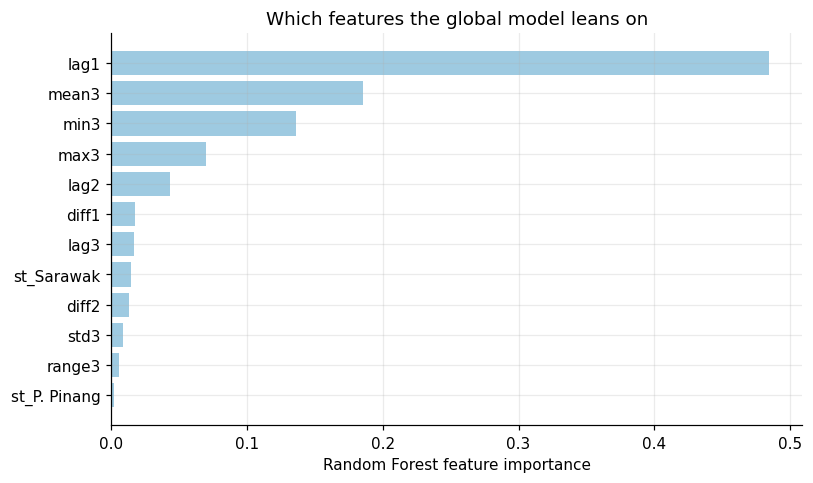

In [25]:
# ── Chart 11: what drives the forecast? (only meaningful for the ML model) ────
importances = pd.Series(rf.feature_importances_, index=X_tr.columns).nlargest(12)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh(importances.index[::-1], importances.values[::-1], color="#9ecae1")
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Which features the global model leans on")
plt.show()

## 8. Export

In [26]:
OUT_XLSX = f"mmwqi_forecast_{FORECAST_YEAR}.xlsx"
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as xw:
    forecast.to_excel(xw, sheet_name=f"forecast_{FORECAST_YEAR}", index=False)
    results.to_excel(xw, sheet_name="model_comparison")
    watchlist.to_excel(xw, sheet_name="watchlist", index=False)
    state_pred.to_excel(xw, sheet_name="state_summary")

forecast.to_csv(f"mmwqi_forecast_{FORECAST_YEAR}.csv", index=False)
print(f"Saved {OUT_XLSX} and mmwqi_forecast_{FORECAST_YEAR}.csv")

Saved mmwqi_forecast_2026.xlsx and mmwqi_forecast_2026.csv


## Notes and caveats

- **Five annual points per station is very little data.** The backtest shows
  simple persistence-style methods are hard to beat; treat the interval, not
  the point estimate, as the real output.
- **The prediction interval is wide by construction** because station-level
  year-on-year swings are large (several MMWQI points on average). A station
  near a category boundary can plausibly land either side of it.
- **No causal drivers are included** — rainfall, discharge permits, new
  developments, sampling date. Adding those would help far more than a fancier
  time-series model.
- **To forecast further ahead** (2027+), re-run the chosen method with a larger
  target year, but widen the interval: error grows roughly with the square root
  of the horizon, so multiply `RESID_SD` by √h.
- **Re-run annually.** When 2026 data arrives, add the column and the backtest
  will re-select the best method automatically.